<a href="https://colab.research.google.com/github/JigishaKakshapati/Netflix_Workbook_Cleanup/blob/main/netflix_workbook_cleanup.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pandas Practice Workbook — Netflix Dataset (125 Questions)
**Prepared by Ananda Rimal** · Dataset: `netflix_titles.csv`

**Columns:** `show_id, type, title, director, cast, country, date_added, release_year, rating, duration, listed_in, description`

**Instructions**
- Write your answer in the code cell **below each question**
- Every answer must be pandas code — no manual counting
- Sections G (GroupBy) and H (Cleaning) may need columns you create along the way — read carefully

| Section | Topic | Questions |
|---------|-------|-----------|
| A | First Analysis of Data | 15 |
| B | Selection with `[]`, `.loc`, `.iloc` | 25 |
| C | Conditions (with `.loc`) | 20 |
| D | Sorting | 10 |
| E | Updating Data | 15 |
| F | GroupBy | 20 |
| G | Cleaning | 20 |
| **Total** | | **125** |

## Section A — First Analysis of Data (Q1–Q15)

#### Q1. Load the dataset into a DataFrame called `df` and display the first 5 rows.

In [ ]:
import pandas as pd

df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


#### Q2. Display the **last 7 rows** of the DataFrame.

In [ ]:
df.tail(7)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8800,s8801,TV Show,Zindagi Gulzar Hai,NaN,"Sanam Saeed, Fawad Khan, Ayesha Omer, Mehreen ...",Pakistan,"December 15, 2016",2012,TV-PG,1 Season,"International TV Shows, Romantic TV Shows, TV ...","Strong-willed, middle-class Kashaf and carefre..."
8801,s8802,Movie,Zinzana,Majid Al Ansari,"Ali Suliman, Saleh Bakri, Yasa, Ali Al-Jabri, ...","United Arab Emirates, Jordan","March 9, 2016",2015,TV-MA,96 min,"Dramas, International Movies, Thrillers",Recovering alcoholic Talal wakes up inside a s...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


#### Q3. How many rows and columns does the dataset have?

In [ ]:
df.shape   # (rows, columns)

(8807, 12)

#### Q4. Display the names of all columns.

In [ ]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

#### Q5. Use `info()` — which columns have missing values, and what is the data type of each column?

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


#### Q6. Use `describe()` on the numeric columns. What is the minimum and maximum `release_year`?

In [ ]:
df.describe()["release_year"][["min","max"]]

,release_year
min,1925.0
max,2021.0


#### Q7. Use `describe(include="object")` on the text columns. Which value appears most often in the `type` column?

In [ ]:
df.describe(include="object")
df["type"].value_counts().idxmax()

'Movie'

#### Q8. Count the missing values in **every** column with one command.

In [ ]:
df.isna().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


#### Q9. Which single column has the **most** missing values?

In [ ]:
df.isna().sum().idxmax()

'director'

#### Q10. How many **unique** values are in the `rating` column? Display them.

In [ ]:
df["rating"].nunique(), df["rating"].unique()

(17,
 array(['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', 'TV-Y', 'TV-Y7', 'R',
        'TV-G', 'G', 'NC-17', '74 min', '84 min', '66 min', 'NR', nan,
        'TV-Y7-FV', 'UR'], dtype=object))

#### Q11. Show 5 **random** rows using `sample()`.

In [ ]:
df.sample(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
3068,s3069,Movie,Pan's Labyrinth,Guillermo del Toro,"Ivana Baquero, Sergi López, Maribel Verdú, Dou...","Mexico, Spain","January 1, 2020",2006,R,119 min,"Dramas, International Movies, Sci-Fi & Fantasy",Young Ofelia meets a mythical faun who claims ...
7839,s7840,Movie,Rebel Without a Cause,Nicholas Ray,"James Dean, Natalie Wood, Sal Mineo, Jim Backu...",United States,"November 1, 2019",1955,PG-13,111 min,"Classic Movies, Dramas",When Jim Stark arrives in a new town with his ...
3030,s3031,TV Show,The Healing Powers of Dude,NaN,"Jace Chapman, Larisa Oleynik, Tom Everett Scot...",NaN,"January 13, 2020",2020,TV-G,1 Season,"Kids' TV, TV Comedies, TV Dramas",When an 11-year-old boy with social anxiety di...
2238,s2239,TV Show,Sunny Bunnies,NaN,"Svetlana Tsimokhina, Dmitri Davidovich",Belarus,"July 15, 2020",2016,TV-Y,2 Seasons,"British TV Shows, Kids' TV, TV Comedies",Furry little bunnies hop through wild adventur...
3840,s3841,TV Show,The Society,NaN,"Kathryn Newton, Gideon Adlon, Sean Berdy, Nata...",United States,"May 10, 2019",2019,TV-MA,1 Season,"TV Dramas, Teen TV Shows",When everyone else mysteriously vanishes from ...


#### Q12. What is the memory usage of the DataFrame? (hint: `info()` or `memory_usage()`)

In [ ]:
df.memory_usage(deep=True).sum()

np.int64(8585948)

#### Q13. Display the data type of only the `release_year` column.

In [ ]:
df["release_year"].dtype

dtype('int64')

#### Q14. Count how many titles are of each `type` using `value_counts()`.

In [ ]:
df["type"].value_counts()

,count
type,
Movie,6131
TV Show,2676


#### Q15. Check: does the dataset contain any **fully duplicated** rows?

In [ ]:
df.duplicated().any()

np.False_

## Section B — Selection with `[]`, `.loc`, `.iloc` (Q16–Q40)
*(Q16–Q30: default 0,1,2,... index · Q31–Q40: after `set_index("show_id")`)*

#### Q16. Select the `title` column as a **Series**.

In [ ]:
df["title"]

,title
0,Dick Johnson Is Dead
1,Blood & Water
2,Ganglands
3,Jailbirds New Orleans
4,Kota Factory
...,...
8802,Zodiac
8803,Zombie Dumb
8804,Zombieland
8805,Zoom


#### Q17. Select the `title` column as a **DataFrame** (hint: double brackets).

In [ ]:
df[["title"]]

,title
0,Dick Johnson Is Dead
1,Blood & Water
2,Ganglands
3,Jailbirds New Orleans
4,Kota Factory
...,...
8802,Zodiac
8803,Zombie Dumb
8804,Zombieland
8805,Zoom


#### Q18. Select the columns `title`, `type`, and `country` together.

In [ ]:
df[["title","type","country"]]

,title,type,country
0,Dick Johnson Is Dead,Movie,United States
1,Blood & Water,TV Show,South Africa
2,Ganglands,TV Show,NaN
3,Jailbirds New Orleans,TV Show,NaN
4,Kota Factory,TV Show,India
...,...,...,...
8802,Zodiac,Movie,United States
8803,Zombie Dumb,TV Show,NaN
8804,Zombieland,Movie,United States
8805,Zoom,Movie,United States


#### Q19. Select the first 10 rows using `.iloc`.

In [ ]:
df.iloc[:10]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...


#### Q20. Select rows with labels 10 to 20 using `.loc`. How many rows do you get and why?

In [ ]:
df.loc[10:20]   # includes both ends → 11 rows

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
10,s11,TV Show,"Vendetta: Truth, Lies and The Mafia",NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, Docuseries, International TV S...","Sicily boasts a bold ""Anti-Mafia"" coalition. B..."
11,s12,TV Show,Bangkok Breaking,Kongkiat Komesiri,"Sukollawat Kanarot, Sushar Manaying, Pavarit M...",NaN,"September 23, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...","Struggling to earn a living in Bangkok, a man ..."
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic","September 23, 2021",2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...
13,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,"Klara Castanho, Lucca Picon, Júlia Gomes, Marc...",NaN,"September 22, 2021",2021,TV-PG,91 min,"Children & Family Movies, Comedies",When the clever but socially-awkward Tetê join...
14,s15,TV Show,Crime Stories: India Detectives,NaN,NaN,NaN,"September 22, 2021",2021,TV-MA,1 Season,"British TV Shows, Crime TV Shows, Docuseries",Cameras following Bengaluru police on the job ...
15,s16,TV Show,Dear White People,NaN,"Logan Browning, Brandon P. Bell, DeRon Horton,...",United States,"September 22, 2021",2021,TV-MA,4 Seasons,"TV Comedies, TV Dramas",Students of color navigate the daily slights a...
16,s17,Movie,Europe's Most Dangerous Man: Otto Skorzeny in ...,"Pedro de Echave García, Pablo Azorín Williams",NaN,NaN,"September 22, 2021",2020,TV-MA,67 min,"Documentaries, International Movies",Declassified documents reveal the post-WWII li...
17,s18,TV Show,Falsa identidad,NaN,"Luis Ernesto Franco, Camila Sodi, Sergio Goyri...",Mexico,"September 22, 2021",2020,TV-MA,2 Seasons,"Crime TV Shows, Spanish-Language TV Shows, TV ...",Strangers Diego and Isabel flee their home in ...
18,s19,Movie,Intrusion,Adam Salky,"Freida Pinto, Logan Marshall-Green, Robert Joh...",NaN,"September 22, 2021",2021,TV-14,94 min,Thrillers,After a deadly home invasion at a couple’s new...
19,s20,TV Show,Jaguar,NaN,"Blanca Suárez, Iván Marcos, Óscar Casas, Adriá...",NaN,"September 22, 2021",2021,TV-MA,1 Season,"International TV Shows, Spanish-Language TV Sh...","In the 1960s, a Holocaust survivor joins a gro..."


#### Q21. Using `.iloc`, select rows at positions 5 to 14 (10 rows). Compare with Q20 — why is the row count logic different?

In [ ]:
df.iloc[5:15]   # excludes end → 10 rows

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...
10,s11,TV Show,"Vendetta: Truth, Lies and The Mafia",NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, Docuseries, International TV S...","Sicily boasts a bold ""Anti-Mafia"" coalition. B..."
11,s12,TV Show,Bangkok Breaking,Kongkiat Komesiri,"Sukollawat Kanarot, Sushar Manaying, Pavarit M...",NaN,"September 23, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...","Struggling to earn a living in Bangkok, a man ..."
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic","September 23, 2021",2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...
13,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,"Klara Castanho, Lucca Picon, Júlia Gomes, Marc...",NaN,"September 22, 2021",2021,TV-PG,91 min,"Children & Family Movies, Comedies",When the clever but socially-awkward Tetê join...
14,s15,TV Show,Crime Stories: India Detectives,NaN,NaN,NaN,"September 22, 2021",2021,TV-MA,1 Season,"British TV Shows, Crime TV Shows, Docuseries",Cameras following Bengaluru police on the job ...


#### Q22. Using `.loc`, select rows 0 to 9 with only the columns `title` and `release_year`.

In [ ]:
df.loc[0:9,["title","release_year"]]

,title,release_year
0,Dick Johnson Is Dead,2020
1,Blood & Water,2021
2,Ganglands,2021
3,Jailbirds New Orleans,2021
4,Kota Factory,2021
5,Midnight Mass,2021
6,My Little Pony: A New Generation,2021
7,Sankofa,1993
8,The Great British Baking Show,2021
9,The Starling,2021


#### Q23. Using `.iloc`, select the first 8 rows and the first 5 columns.

In [ ]:
df.iloc[:8,:5]

,show_id,type,title,director,cast
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi..."
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K..."
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H..."
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ..."
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D..."


#### Q24. Using `.iloc`, select the **last row** of the DataFrame.

In [ ]:
df.iloc[-1]

,8806
show_id,s8807
type,Movie
title,Zubaan
director,Mozez Singh
cast,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan..."
country,India
date_added,"March 2, 2019"
release_year,2015
rating,TV-14
duration,111 min


#### Q25. Using `.iloc`, select the last 5 rows and the last 2 columns (negative positions).

In [ ]:
df.iloc[-5:,-2:]

,listed_in,description
8802,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


#### Q26. Using `.loc`, get the value of `title` for the row with label 50.

In [ ]:
df.loc[50,"title"]

'Dharmakshetra'

#### Q27. Using `.iloc`, get the value in row position 100, column position 2. Which column is that?

In [ ]:
df.iloc[100,2]   # column at position 2 is "title"

'Tobot Galaxy Detectives'

#### Q28. Using `.iloc`, select every 100th row (hint: slicing with a step `::100`).

In [ ]:
df.iloc[::100]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
100,s101,TV Show,Tobot Galaxy Detectives,NaN,"Austin Abell, Travis Turner, Cole Howard, Anna...",NaN,"September 7, 2021",2019,TV-Y7,2 Seasons,Kids' TV,An intergalactic device transforms toy cars in...
200,s201,Movie,Krishna Cottage,Santram Varma,"Sohail Khan, Isha Koppikar, Natassha, Rati Agn...",India,"August 27, 2021",2004,TV-14,124 min,"Action & Adventure, Horror Movies, Internation...",True love is put to the test when another woma...
300,s301,Movie,Vivo,"Kirk DeMicco, Brandon Jeffords","Lin-Manuel Miranda, Ynairaly Simo, Zoe Saldana...","Canada, United States","August 6, 2021",2021,PG,100 min,"Children & Family Movies, Music & Musicals",A music-loving kinkajou embarks on the journey...
400,s401,TV Show,Revelations: The Masters of the Universe: Reve...,NaN,"Kevin Smith, Tiffany Smith, Robert David, Sara...",NaN,"July 23, 2021",2021,TV-PG,1 Season,"Anime Series, Stand-Up Comedy & Talk Shows",Take a behind-the-scenes look at “Masters of t...
...,...,...,...,...,...,...,...,...,...,...,...,...
8400,s8401,Movie,The Long Goodbye: The Kara Tippetts Story,Jay Lyons,NaN,United States,"June 23, 2019",2019,TV-PG,87 min,"Documentaries, Faith & Spirituality","Faced with terminal breast cancer, a courageou..."
8500,s8501,Movie,The Search for Life in Space,Stephen Amezdroz,NaN,United States,"April 1, 2018",2016,TV-G,32 min,Documentaries,To determine whether we're alone in the univer...
8600,s8601,TV Show,Tobot,NaN,"Octavian Kaul, Valin Shinyei, Chelsea Miller, ...",Canada,"September 11, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows",They’re robots that can transform into cars – ...
8700,s8701,TV Show,Wartime Portraits,NaN,NaN,Poland,"September 15, 2016",2014,TV-MA,1 Season,"Docuseries, International TV Shows","Part live-action and part animation, this visu..."


#### Q29. Using `.loc`, select rows 0 to 4 and **all** columns from `title` to `country` (label slicing on columns!).

In [ ]:
df.loc[0:4,"title":"country"]

,title,director,cast,country
0,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States
1,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa
2,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN
3,Jailbirds New Orleans,NaN,NaN,NaN
4,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India


#### Q30. Select three specific rows by label — 3, 33, and 333 — in one `.loc` call.

In [ ]:
df.loc[[3,33,333]]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
33,s34,TV Show,Squid Game,NaN,"Lee Jung-jae, Park Hae-soo, Wi Ha-jun, Oh Youn...",NaN,"September 17, 2021",2021,TV-MA,1 Season,"International TV Shows, TV Dramas, TV Thrillers",Hundreds of cash-strapped players accept a str...
333,s334,Movie,Ferris Bueller's Day Off,John Hughes,"Matthew Broderick, Alan Ruck, Mia Sara, Jeffre...",United States,"August 1, 2021",1986,PG-13,103 min,"Classic Movies, Comedies, Cult Movies","After faking an illness to skip school, popula..."


#### Q31. Set `show_id` as the index of `df` (keep it for the rest of Section B). Display the head.

In [ ]:
df.set_index("show_id", inplace=True)
df.head()

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
show_id,,,,,,,,,,,
s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


#### Q32. Using `.loc`, select the row with label `"s1"`.

In [ ]:
df.loc["s1"]

,s1
type,Movie
title,Dick Johnson Is Dead
director,Kirsten Johnson
cast,NaN
country,United States
date_added,"September 25, 2021"
release_year,2020
rating,PG-13
duration,90 min
listed_in,Documentaries


#### Q33. Using `.loc`, select rows `"s10"` to `"s15"`. Does label slicing still include the end?

In [ ]:
df.loc["s10":"s15"]


,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
show_id,,,,,,,,,,,
s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...
s11,TV Show,"Vendetta: Truth, Lies and The Mafia",NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, Docuseries, International TV S...","Sicily boasts a bold ""Anti-Mafia"" coalition. B..."
s12,TV Show,Bangkok Breaking,Kongkiat Komesiri,"Sukollawat Kanarot, Sushar Manaying, Pavarit M...",NaN,"September 23, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...","Struggling to earn a living in Bangkok, a man ..."
s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic","September 23, 2021",2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...
s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,"Klara Castanho, Lucca Picon, Júlia Gomes, Marc...",NaN,"September 22, 2021",2021,TV-PG,91 min,"Children & Family Movies, Comedies",When the clever but socially-awkward Tetê join...
s15,TV Show,Crime Stories: India Detectives,NaN,NaN,NaN,"September 22, 2021",2021,TV-MA,1 Season,"British TV Shows, Crime TV Shows, Docuseries",Cameras following Bengaluru police on the job ...


#### Q34. Using `.iloc`, select the row at position 0. Is it the same row as label `"s1"`?

In [ ]:
df.iloc[0]   # same row as "s1" if index is sorted

,s1
type,Movie
title,Dick Johnson Is Dead
director,Kirsten Johnson
cast,NaN
country,United States
date_added,"September 25, 2021"
release_year,2020
rating,PG-13
duration,90 min
listed_in,Documentaries


#### Q35. Using `.loc`, get the `title` and `type` of the show with id `"s500"`.

In [ ]:
df.loc["s500", ["title", "type"]]


,s500
title,Dogs
type,TV Show


#### Q36. Using `.iloc`, select the row at position 499. Is its label `"s500"`? Explain why or why not in a comment.

In [ ]:
df.iloc[499]   # label is "s500" because indexing starts at 1

,s500
type,TV Show
title,Dogs
director,NaN
cast,NaN
country,United States
date_added,"July 7, 2021"
release_year,2021
rating,TV-PG
duration,2 Seasons
listed_in,Docuseries


#### Q37. Using `.loc`, select shows `"s1"`, `"s100"`, and `"s1000"` with columns `title` and `release_year`.

In [ ]:
df.loc[["s1","s100","s1000"],["title","release_year"]]

,title,release_year
show_id,,
s1,Dick Johnson Is Dead,2020
s100,On the Verge,2021
s1000,Stowaway,2021


#### Q38. What happens if you run `df.loc[0]` now? Try it, read the error, and explain in a comment.

In [ ]:
#df.loc[0]

# This throws the KeyError, because index is show_id not numbers

#### Q39. Using `.iloc`, select rows at positions [0, 99, 999] in one call.

In [ ]:
df.iloc[[0,99,999]]

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
show_id,,,,,,,,,,,
s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
s100,TV Show,On the Verge,NaN,"Julie Delpy, Elisabeth Shue, Sarah Jones, Alex...","France, United States","September 7, 2021",2021,TV-MA,1 Season,"TV Comedies, TV Dramas","Four women — a chef, a single mom, an heiress ..."
s1000,Movie,Stowaway,Joe Penna,"Anna Kendrick, Toni Collette, Daniel Dae Kim, ...","Germany, United States","April 22, 2021",2021,TV-MA,116 min,"Dramas, International Movies, Thrillers",A three-person crew on a mission to Mars faces...


#### Q40. Reset the index back to 0,1,2,... using `reset_index()`. Display the head.

In [ ]:
df.reset_index(inplace=True)
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## Section C — Conditions with `.loc` (Q41–Q60)
*Write every filter with `df.loc[condition]` or `df.loc[condition, columns]` style where possible.*

#### Q41. Select all rows where `type` is `"Movie"`.

In [ ]:
df.loc[df["type"]=="Movie"]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic","September 23, 2021",2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...
...,...,...,...,...,...,...,...,...,...,...,...,...
8801,s8802,Movie,Zinzana,Majid Al Ansari,"Ali Suliman, Saleh Bakri, Yasa, Ali Al-Jabri, ...","United Arab Emirates, Jordan","March 9, 2016",2015,TV-MA,96 min,"Dramas, International Movies, Thrillers",Recovering alcoholic Talal wakes up inside a s...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


#### Q42. Select all rows where `type` is `"TV Show"` — show only `title` and `country` using one `.loc` call.

In [ ]:
df.loc[df["type"]=="TV Show", ["title", "country"]]


,title,country
1,Blood & Water,South Africa
2,Ganglands,NaN
3,Jailbirds New Orleans,NaN
4,Kota Factory,India
5,Midnight Mass,NaN
...,...,...
8795,Yu-Gi-Oh! Arc-V,"Japan, Canada"
8796,Yunus Emre,Turkey
8797,Zak Storm,"United States, France, South Korea, Indonesia"
8800,Zindagi Gulzar Hai,Pakistan


#### Q43. Select all titles released in 2021.

In [ ]:
df.loc[df["release_year"]==2021]


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
...,...,...,...,...,...,...,...,...,...,...,...,...
1468,s1469,Movie,What Happened to Mr. Cha?,Kim Dong-kyu,"Cha In-pyo, Cho Dal-hwan, Song Jae-ryong",South Korea,"January 1, 2021",2021,TV-MA,102 min,"Comedies, International Movies","With the peak of his career long behind him, a..."
1551,s1552,TV Show,Hilda,NaN,"Bella Ramsey, Ameerah Falzon-Ojo, Oliver Nelso...","United Kingdom, Canada, United States","December 14, 2020",2021,TV-Y7,2 Seasons,Kids' TV,"Fearless, free-spirited Hilda finds new friend..."
1696,s1697,TV Show,Polly Pocket,NaN,"Emily Tennant, Shannon Chan-Kent, Kazumi Evans...","Canada, United States, Ireland","November 15, 2020",2021,TV-Y,2 Seasons,Kids' TV,After uncovering a magical locket that allows ...
2920,s2921,TV Show,Love Is Blind,NaN,"Nick Lachey, Vanessa Lachey",United States,"February 13, 2020",2021,TV-MA,1 Season,"Reality TV, Romantic TV Shows",Nick and Vanessa Lachey host this social exper...


#### Q44. Select all titles released **before** 2000.

In [ ]:
df.loc[df["release_year"]<2021]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
16,s17,Movie,Europe's Most Dangerous Man: Otto Skorzeny in ...,"Pedro de Echave García, Pablo Azorín Williams",NaN,NaN,"September 22, 2021",2020,TV-MA,67 min,"Documentaries, International Movies",Declassified documents reveal the post-WWII li...
17,s18,TV Show,Falsa identidad,NaN,"Luis Ernesto Franco, Camila Sodi, Sergio Goyri...",Mexico,"September 22, 2021",2020,TV-MA,2 Seasons,"Crime TV Shows, Spanish-Language TV Shows, TV ...",Strangers Diego and Isabel flee their home in ...
21,s22,TV Show,Resurrection: Ertugrul,NaN,"Engin Altan Düzyatan, Serdar Gökhan, Hülya Dar...",Turkey,"September 22, 2021",2018,TV-14,5 Seasons,"International TV Shows, TV Action & Adventure,...",When a good deed unwittingly endangers his cla...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


#### Q45. Select all titles released between 2015 and 2020 (inclusive) — two conditions with `&`.

In [ ]:
df.loc[(df["release_year"]>2015) & (df["release_year"]<2020)]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
21,s22,TV Show,Resurrection: Ertugrul,NaN,"Engin Altan Düzyatan, Serdar Gökhan, Hülya Dar...",Turkey,"September 22, 2021",2018,TV-14,5 Seasons,"International TV Shows, TV Action & Adventure,...",When a good deed unwittingly endangers his cla...
37,s38,TV Show,Angry Birds,NaN,"Antti Pääkkönen, Heljä Heikkinen, Lynne Guagli...",Finland,"September 16, 2021",2018,TV-Y7,1 Season,"Kids' TV, TV Comedies","Birds Red, Chuck and their feathered friends h..."
38,s39,Movie,Birth of the Dragon,George Nolfi,"Billy Magnussen, Ron Yuan, Qu Jingjing, Terry ...","China, Canada, United States","September 16, 2021",2017,PG-13,96 min,"Action & Adventure, Dramas",A young Bruce Lee angers kung fu traditionalis...
73,s74,Movie,King of Boys,Kemi Adetiba,"Sola Sobowale, Adesua Etomi, Remilekun ""Remini...",Nigeria,"September 14, 2021",2018,TV-MA,182 min,"Dramas, International Movies",When a powerful businesswoman’s political ambi...
87,s88,TV Show,Titipo Titipo,NaN,"Jeon Hae-ri, Kim Eun-ah, Hong Bum-ki, Nam Do-h...",NaN,"September 10, 2021",2019,TV-Y,2 Seasons,"Kids' TV, Korean TV Shows",Titipo the train is out to prove that he's got...
...,...,...,...,...,...,...,...,...,...,...,...,...
8787,s8788,Movie,You Can’t Fight Christmas,Kenny Young,"Brely Evans, Andra Fuller, Persia White, Porsc...",United States,"December 19, 2017",2017,TV-PG,85 min,"Comedies, Romantic Movies",After stepping in to revitalize his family's h...
8794,s8795,Movie,اشتباك,Mohamed Diab,"Nelly Karim, Hany Adel, Tarek Abdel Aziz, Ahme...","Egypt, France","October 11, 2018",2016,TV-14,98 min,"Dramas, Independent Movies, International Movies",Amid the tumult following Egyptian President M...
8796,s8797,TV Show,Yunus Emre,NaN,"Gökhan Atalay, Payidar Tüfekçioglu, Baran Akbu...",Turkey,"January 17, 2017",2016,TV-PG,2 Seasons,"International TV Shows, TV Dramas","During the Mongol invasions, Yunus Emre leaves..."
8797,s8798,TV Show,Zak Storm,NaN,"Michael Johnston, Jessica Gee-George, Christin...","United States, France, South Korea, Indonesia","September 13, 2018",2016,TV-Y7,3 Seasons,Kids' TV,Teen surfer Zak Storm is mysteriously transpor...


#### Q46. Select all Movies released after 2019 (two conditions).

In [ ]:
df.loc[(df["type"]=="Movie") & (df["release_year"]>2019)]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic","September 23, 2021",2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...
13,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,"Klara Castanho, Lucca Picon, Júlia Gomes, Marc...",NaN,"September 22, 2021",2021,TV-PG,91 min,"Children & Family Movies, Comedies",When the clever but socially-awkward Tetê join...
...,...,...,...,...,...,...,...,...,...,...,...,...
3046,s3047,Movie,All the Freckles in the World,Yibrán Asuad,"Hánssel Casillas, Loreto Peralta, Andrea Sutto...",Mexico,"January 3, 2020",2020,TV-14,90 min,"Comedies, International Movies, Romantic Movies",Thirteen-year-old José Miguel is immune to 199...
3060,s3061,Movie,Ghost Stories,"Anurag Kashyap, Dibakar Banerjee, Karan Johar,...","Janhvi Kapoor, Sobhita Dhulipala, Sukant Goel,...",India,"January 1, 2020",2020,TV-MA,145 min,"Horror Movies, International Movies, Thrillers","The directors of Emmy-nominated ""Lust Stories""..."
5972,s5973,Movie,#cats_the_mewvie,Michael Margolis,NaN,Canada,"February 5, 2020",2020,TV-14,90 min,"Documentaries, International Movies",This pawesome documentary explores how our fel...
7594,s7595,Movie,Norm of the North: Family Vacation,Anthony Bell,"Andrew Toth, Lisa Durupt, Jonathan Holmes, Pau...",United States,"May 25, 2020",2020,TV-Y7,89 min,Children & Family Movies,"Stressed by his duties as king and father, Nor..."


#### Q47. Select all titles where `rating` is `"TV-MA"`.

In [ ]:
df.loc[(df["rating"]=="TV-MA")]


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
...,...,...,...,...,...,...,...,...,...,...,...,...
8762,s8763,Movie,Wrong Side Raju,Mikhil Musale,"Pratik Gandhi, Kimberley Louisa McBeath, Asif ...",India,"October 1, 2017",2016,TV-MA,140 min,"Dramas, International Movies",The life of a chauffeur and part-time bootlegg...
8769,s8770,Movie,Y.M.I.: Yeh Mera India,N. Chandra,"Anupam Kher, Atul Kulkarni, Aakash Pandey, Mil...",India,"March 1, 2018",2008,TV-MA,137 min,"Dramas, Independent Movies, International Movies","The lives of a middle-aged soap opera addict, ..."
8788,s8789,Movie,You Carry Me,Ivona Juka,"Lana Baric, Vojislav Brajovic, Natasa Janjic, ...","Croatia, Slovenia, Serbia, Montenegro","July 1, 2016",2015,TV-MA,157 min,"Dramas, International Movies","A soap opera producer, director and makeup art..."
8798,s8799,Movie,Zed Plus,Chandra Prakash Dwivedi,"Adil Hussain, Mona Singh, K.K. Raina, Sanjay M...",India,"December 31, 2019",2014,TV-MA,131 min,"Comedies, Dramas, International Movies",A philandering small-town mechanic's political...


#### Q48. Select all titles where `rating` is either `"PG"` or `"PG-13"` using `.isin()`.

In [ ]:
df.loc[df["rating"].isin(["PG", "PG-13"])]


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...
27,s28,Movie,Grown Ups,Dennis Dugan,"Adam Sandler, Kevin James, Chris Rock, David S...",United States,"September 20, 2021",2010,PG-13,103 min,Comedies,Mourning the loss of their beloved junior high...
28,s29,Movie,Dark Skies,Scott Stewart,"Keri Russell, Josh Hamilton, J.K. Simmons, Dak...",United States,"September 19, 2021",2013,PG-13,97 min,"Horror Movies, Sci-Fi & Fantasy",A family’s idyllic suburban life shatters when...
...,...,...,...,...,...,...,...,...,...,...,...,...
8767,s8768,Movie,XXX: State of the Union,Lee Tamahori,"Ice Cube, Samuel L. Jackson, Willem Dafoe, Sco...",United States,"January 1, 2019",2005,PG-13,101 min,Action & Adventure,"In this action-packed follow-up to XXX, U.S. i..."
8776,s8777,Movie,Yellowbird,Christian De Vita,"Dakota Fanning, Seth Green, Christine Baranski...","France, Belgium","August 5, 2015",2014,PG,90 min,"Children & Family Movies, Comedies",An orphaned bird tags along with a flock on th...
8782,s8783,Movie,Yoga Hosers,Kevin Smith,"Harley Quinn Smith, Lily-Rose Depp, Johnny Dep...",United States,"December 2, 2016",2016,PG-13,88 min,"Comedies, Horror Movies, Independent Movies",With an all-important high school party at sta...
8793,s8794,Movie,"Yours, Mine and Ours",Raja Gosnell,"Dennis Quaid, Rene Russo, Sean Faris, Katija P...",United States,"November 20, 2019",2005,PG,88 min,"Children & Family Movies, Comedies",When a father of eight and a mother of 10 prep...


#### Q49. Select all titles where `rating` is **NOT** `"TV-MA"` (hint: `~` or `!=`).

In [ ]:
df.loc[df["rating"]!="TV-MA"]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...
13,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,"Klara Castanho, Lucca Picon, Júlia Gomes, Marc...",NaN,"September 22, 2021",2021,TV-PG,91 min,"Children & Family Movies, Comedies",When the clever but socially-awkward Tetê join...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


#### Q50. Select all titles where `country` is exactly `"India"`.

In [ ]:
df.loc[df["country"]=="India"]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
24,s25,Movie,Jeans,S. Shankar,"Prashanth, Aishwarya Rai Bachchan, Sri Lakshmi...",India,"September 21, 2021",1998,TV-14,166 min,"Comedies, International Movies, Romantic Movies",When the father of the man she loves insists t...
39,s40,TV Show,Chhota Bheem,NaN,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",India,"September 16, 2021",2021,TV-Y7,3 Seasons,Kids' TV,"A brave, energetic little boy with superhuman ..."
50,s51,TV Show,Dharmakshetra,NaN,"Kashmira Irani, Chandan Anand, Dinesh Mehta, A...",India,"September 15, 2021",2014,TV-PG,1 Season,"International TV Shows, TV Dramas, TV Sci-Fi &...","After the ancient Great War, the god Chitragup..."
66,s67,TV Show,Raja Rasoi Aur Anya Kahaniyan,NaN,NaN,India,"September 15, 2021",2014,TV-G,1 Season,"Docuseries, International TV Shows",Explore the history and flavors of regional In...
...,...,...,...,...,...,...,...,...,...,...,...,...
8773,s8774,Movie,Yanda Kartavya Aahe,Kedar Shinde,"Ankush Choudhary, Smita Shewale, Mohan Joshi, ...",India,"January 1, 2018",2006,TV-PG,151 min,"Comedies, Dramas, International Movies",Thanks to an arranged marriage that was design...
8775,s8776,TV Show,Yeh Meri Family,NaN,"Vishesh Bansal, Mona Singh, Akarsh Khurana, Ah...",India,"August 31, 2018",2018,TV-PG,1 Season,"International TV Shows, TV Comedies","In the summer of 1998, middle child Harshu bal..."
8798,s8799,Movie,Zed Plus,Chandra Prakash Dwivedi,"Adil Hussain, Mona Singh, K.K. Raina, Sanjay M...",India,"December 31, 2019",2014,TV-MA,131 min,"Comedies, Dramas, International Movies",A philandering small-town mechanic's political...
8799,s8800,Movie,Zenda,Avadhoot Gupte,"Santosh Juvekar, Siddharth Chandekar, Sachit P...",India,"February 15, 2018",2009,TV-14,120 min,"Dramas, International Movies",A change in the leadership of a political part...


#### Q51. Select all titles where `country` **contains** `"India"` (hint: `str.contains`, use `na=False`). Why is the row count different from the previous question?

In [ ]:
df.loc[df["country"].str.contains("India",na=False)]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
24,s25,Movie,Jeans,S. Shankar,"Prashanth, Aishwarya Rai Bachchan, Sri Lakshmi...",India,"September 21, 2021",1998,TV-14,166 min,"Comedies, International Movies, Romantic Movies",When the father of the man she loves insists t...
29,s30,Movie,Paranoia,Robert Luketic,"Liam Hemsworth, Gary Oldman, Amber Heard, Harr...","United States, India, France","September 19, 2021",2013,PG-13,106 min,Thrillers,"Blackmailed by his company's CEO, a low-level ..."
39,s40,TV Show,Chhota Bheem,NaN,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",India,"September 16, 2021",2021,TV-Y7,3 Seasons,Kids' TV,"A brave, energetic little boy with superhuman ..."
50,s51,TV Show,Dharmakshetra,NaN,"Kashmira Irani, Chandan Anand, Dinesh Mehta, A...",India,"September 15, 2021",2014,TV-PG,1 Season,"International TV Shows, TV Dramas, TV Sci-Fi &...","After the ancient Great War, the god Chitragup..."
...,...,...,...,...,...,...,...,...,...,...,...,...
8773,s8774,Movie,Yanda Kartavya Aahe,Kedar Shinde,"Ankush Choudhary, Smita Shewale, Mohan Joshi, ...",India,"January 1, 2018",2006,TV-PG,151 min,"Comedies, Dramas, International Movies",Thanks to an arranged marriage that was design...
8775,s8776,TV Show,Yeh Meri Family,NaN,"Vishesh Bansal, Mona Singh, Akarsh Khurana, Ah...",India,"August 31, 2018",2018,TV-PG,1 Season,"International TV Shows, TV Comedies","In the summer of 1998, middle child Harshu bal..."
8798,s8799,Movie,Zed Plus,Chandra Prakash Dwivedi,"Adil Hussain, Mona Singh, K.K. Raina, Sanjay M...",India,"December 31, 2019",2014,TV-MA,131 min,"Comedies, Dramas, International Movies",A philandering small-town mechanic's political...
8799,s8800,Movie,Zenda,Avadhoot Gupte,"Santosh Juvekar, Siddharth Chandekar, Sachit P...",India,"February 15, 2018",2009,TV-14,120 min,"Dramas, International Movies",A change in the leadership of a political part...


#### Q52. Select all Movies from the United States — show only `title` and `release_year`.

In [ ]:
df.loc[(df["country"] == "United States"), ["title", "release_year"]]

,title,release_year
0,Dick Johnson Is Dead,2020
9,The Starling,2021
15,Dear White People,2021
27,Grown Ups,2010
28,Dark Skies,2013
...,...,...
8791,Young Adult,2011
8793,"Yours, Mine and Ours",2005
8802,Zodiac,2007
8804,Zombieland,2009


#### Q53. Select all titles where `director` is missing (hint: `isna()`).

In [ ]:
df.loc[df["director"].isna()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
10,s11,TV Show,"Vendetta: Truth, Lies and The Mafia",NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, Docuseries, International TV S...","Sicily boasts a bold ""Anti-Mafia"" coalition. B..."
14,s15,TV Show,Crime Stories: India Detectives,NaN,NaN,NaN,"September 22, 2021",2021,TV-MA,1 Season,"British TV Shows, Crime TV Shows, Docuseries",Cameras following Bengaluru police on the job ...
...,...,...,...,...,...,...,...,...,...,...,...,...
8795,s8796,TV Show,Yu-Gi-Oh! Arc-V,NaN,"Mike Liscio, Emily Bauer, Billy Bob Thompson, ...","Japan, Canada","May 1, 2018",2015,TV-Y7,2 Seasons,"Anime Series, Kids' TV",Now that he's discovered the Pendulum Summonin...
8796,s8797,TV Show,Yunus Emre,NaN,"Gökhan Atalay, Payidar Tüfekçioglu, Baran Akbu...",Turkey,"January 17, 2017",2016,TV-PG,2 Seasons,"International TV Shows, TV Dramas","During the Mongol invasions, Yunus Emre leaves..."
8797,s8798,TV Show,Zak Storm,NaN,"Michael Johnston, Jessica Gee-George, Christin...","United States, France, South Korea, Indonesia","September 13, 2018",2016,TV-Y7,3 Seasons,Kids' TV,Teen surfer Zak Storm is mysteriously transpor...
8800,s8801,TV Show,Zindagi Gulzar Hai,NaN,"Sanam Saeed, Fawad Khan, Ayesha Omer, Mehreen ...",Pakistan,"December 15, 2016",2012,TV-PG,1 Season,"International TV Shows, Romantic TV Shows, TV ...","Strong-willed, middle-class Kashaf and carefre..."


#### Q54. Select all titles where `director` is **not** missing.

In [ ]:
df.loc[df["director"].notna()]


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
...,...,...,...,...,...,...,...,...,...,...,...,...
8801,s8802,Movie,Zinzana,Majid Al Ansari,"Ali Suliman, Saleh Bakri, Yasa, Ali Al-Jabri, ...","United Arab Emirates, Jordan","March 9, 2016",2015,TV-MA,96 min,"Dramas, International Movies, Thrillers",Recovering alcoholic Talal wakes up inside a s...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


#### Q55. Select all TV Shows released in 2020 **or** 2021.

In [ ]:
df.loc[(df["type"]=="TV Show") & (df["release_year"].isin([2020,2021]))]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
...,...,...,...,...,...,...,...,...,...,...,...,...
3369,s3370,TV Show,BoJack Horseman,NaN,"Will Arnett, Aaron Paul, Amy Sedaris, Alison B...",United States,"October 25, 2019",2020,TV-MA,6 Seasons,TV Comedies,Meet the most beloved sitcom horse of the '90s...
3433,s3434,TV Show,The Hook Up Plan,NaN,"Marc Ruchmann, Zita Hanrot, Sabrina Ouazani, J...",France,"October 11, 2019",2020,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...","When Parisian Elsa gets hung up on her ex, her..."
8125,s8126,TV Show,Super Wings,NaN,"Luca Padovan, Evan Smolin, Junah Jang, Colin C...","United States, South Korea, China","December 1, 2020",2020,TV-Y,3 Seasons,"Kids' TV, Korean TV Shows",A cheerful jet and his transforming pals striv...
8132,s8133,TV Show,Surviving R. Kelly Part II: The Reckoning,NaN,R. Kelly,United States,"April 13, 2020",2020,TV-MA,1 Season,"Crime TV Shows, Docuseries",As more women come forward with harrowing accu...


#### Q56. Select all titles whose `title` starts with the letter `"A"` (hint: `str.startswith`, `na=False`).

In [ ]:
df.loc[df["title"].str.startswith("A",na=False)]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
22,s23,Movie,Avvai Shanmughi,K.S. Ravikumar,"Kamal Hassan, Meena, Gemini Ganesan, Heera Raj...",NaN,"September 21, 2021",1996,TV-PG,161 min,"Comedies, International Movies",Newly divorced and denied visitation rights wi...
30,s31,Movie,Ankahi Kahaniya,"Ashwiny Iyer Tiwari, Abhishek Chaubey, Saket C...","Abhishek Banerjee, Rinku Rajguru, Delzad Hiwal...",NaN,"September 17, 2021",2021,TV-14,111 min,"Dramas, Independent Movies, International Movies","As big city life buzzes around them, lonely so..."
37,s38,TV Show,Angry Birds,NaN,"Antti Pääkkönen, Heljä Heikkinen, Lynne Guagli...",Finland,"September 16, 2021",2018,TV-Y7,1 Season,"Kids' TV, TV Comedies","Birds Red, Chuck and their feathered friends h..."
71,s72,Movie,A StoryBots Space Adventure,David A. Vargas,"Evan Spiridellis, Erin Fitzgerald, Jeff Gill, ...",NaN,"September 14, 2021",2021,TV-Y,13 min,Children & Family Movies,Join the StoryBots and the space travelers of ...
105,s106,Movie,Angamaly Diaries,Lijo Jose Pellissery,"Antony Varghese, Reshma Rajan, Binny Rinky Ben...",India,"September 5, 2021",2017,TV-14,128 min,"Action & Adventure, Comedies, Dramas",After growing up amidst the gang wars of his h...
...,...,...,...,...,...,...,...,...,...,...,...,...
6198,s6199,TV Show,Aussie Gold Hunters,NaN,NaN,Australia,"August 1, 2017",2016,TV-MA,1 Season,"Docuseries, International TV Shows, Reality TV",Three teams of gold hunters battle all manner ...
6199,s6200,Movie,Automata,Gabe Ibáñez,"Antonio Banderas, Dylan McDermott, Melanie Gri...","Bulgaria, United States, Spain, Canada","September 8, 2017",2014,R,110 min,"International Movies, Sci-Fi & Fantasy, Thrillers","In a dystopian future, an insurance adjuster f..."
6200,s6201,Movie,Avengers: Infinity War,"Anthony Russo, Joe Russo","Robert Downey Jr., Josh Brolin, Mark Ruffalo, ...",United States,"December 25, 2018",2018,PG-13,150 min,"Action & Adventure, Sci-Fi & Fantasy",Superheroes amass to stop intergalactic sociop...
6201,s6202,Movie,Avicii: True Stories,Levan Tsikurishvili,Avicii,"Sweden, Netherlands","December 28, 2018",2017,TV-MA,97 min,"Documentaries, International Movies, Music & M...","Follow the meteoric rise of Tim Bergling, aka ..."


#### Q57. Select all titles whose `title` contains the word `"Love"`.

In [ ]:
df.loc[df["title"].str.contains("Love")]


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
25,s26,TV Show,Love on the Spectrum,NaN,Brooke Satchwell,Australia,"September 21, 2021",2021,TV-14,2 Seasons,"Docuseries, International TV Shows, Reality TV",Finding love can be hard for anyone. For young...
158,s159,Movie,Love Don't Cost a Thing,Troy Byer,"Nick Cannon, Christina Milian, Kenan Thompson,...",United States,"September 1, 2021",2003,PG-13,101 min,"Comedies, Romantic Movies",A nerdy teen tries to make himself cool by ass...
159,s160,Movie,Love in a Puff,Pang Ho-cheung,"Miriam Chin Wah Yeung, Shawn Yue, Singh Hartih...",Hong Kong,"September 1, 2021",2010,TV-MA,103 min,"Comedies, Dramas, International Movies",When the Hong Kong government enacts a ban on ...
206,s207,Movie,"LSD: Love, Sex Aur Dhokha",Dibakar Banerjee,"Nushrat Bharucha, Anshuman Jha, Neha Chauhan, ...",India,"August 27, 2021",2010,TV-MA,112 min,"Dramas, Independent Movies, International Movies",This provocative drama examines how the voyeur...
227,s228,Movie,Really Love,Angel Kristi Williams,"Kofi Siriboe, Yootha Wong-Loi-Sing, Michael Ea...",United States,"August 25, 2021",2020,TV-MA,95 min,"Dramas, Independent Movies, Romantic Movies",A rising Black painter tries to break into a c...
...,...,...,...,...,...,...,...,...,...,...,...,...
8567,s8568,TV Show,The Year of Happiness and Love,NaN,"Amber Kuo, James Wen, Weber Yang, Sonia Sui, N...",Taiwan,"September 1, 2016",2009,TV-PG,1 Season,"International TV Shows, Romantic TV Shows, TV ...",Jiang Chen-bo is a loser without prospects for...
8575,s8576,TV Show,This Is My Love,NaN,"Jin-mo Joo, Sa-rang Kim, Junior, Ja-in Lee, Su...",South Korea,"May 22, 2017",2015,TV-14,1 Season,"International TV Shows, Korean TV Shows, Roman...",A renowned actor who is still pining over the ...
8649,s8650,Movie,Two Lovers and a Bear,Kim Nguyen,"Dane DeHaan, Tatiana Maslany, Gordon Pinsent, ...",Canada,"May 2, 2017",2016,R,95 min,"Dramas, Independent Movies, Romantic Movies",A troubled couple living near the North Pole b...
8721,s8722,TV Show,What Is Love?,NaN,"Chris Wu, Jade Chou, Duncan Lai, King Chin, Ki...",Taiwan,"January 1, 2017",2012,TV-14,1 Season,"International TV Shows, Romantic TV Shows, TV ...",A 32-year-old romantic looking for a long-term...


#### Q58. Using `.loc` with a condition, show the `title`, `rating`, and `release_year` of all Movies rated `"R"`.

In [ ]:
df.loc[(df["rating"]=="R"), ["title", "rating", "release_year"]]


,title,rating,release_year
46,Safe House,R,2012
48,Training Day,R,2001
81,Kate,R,2021
122,In the Cut,R,2003
131,Blade Runner: The Final Cut,R,1982
...,...,...,...
8765,XX,R,2017
8768,Y Tu Mamá También,R,2001
8791,Young Adult,R,2011
8802,Zodiac,R,2007


#### Q59. Count how many Movies were released after 2015 (condition + `len()` or `.shape`).

In [ ]:
len(df.loc[(df["type"]=="Movie") & (df["release_year"]>2015)])

3619

#### Q60. Challenge: select all Movies that are from India **or** Nepal and released after 2010 — careful with brackets around the `|` condition!

In [ ]:
df.loc[(df["type"]=="Movie") & ((df["country"].isin(["India","Nepal"])) & (df["release_year"]>2010))]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
105,s106,Movie,Angamaly Diaries,Lijo Jose Pellissery,"Antony Varghese, Reshma Rajan, Binny Rinky Ben...",India,"September 5, 2021",2017,TV-14,128 min,"Action & Adventure, Comedies, Dramas",After growing up amidst the gang wars of his h...
116,s117,Movie,Dhanak,Nagesh Kukunoor,"Krrish Chhabria, Hetal Gada, Vipin Sharma, Gul...",India,"September 2, 2021",2015,TV-PG,114 min,"Comedies, Dramas, Independent Movies",A movie-loving 10-year-old and her blind littl...
118,s119,Movie,Gurgaon,Shanker Raman,"Akshay Oberoi, Pankaj Tripathi, Ragini Khanna,...",India,"September 2, 2021",2017,TV-14,106 min,"Dramas, International Movies, Thrillers",When the daughter of a wealthy family returns ...
126,s127,Movie,Shikara,Vidhu Vinod Chopra,"Aadil Khan, Sadia Khateeb, Zain Khan Durrani, ...",India,"September 2, 2021",2020,TV-14,115 min,"Dramas, International Movies, Romantic Movies",A couple must strive to remain resilient after...
190,s191,Movie,Thimmarusu,Sharan Koppisetty,"Satya Dev, Priyanka Jawalkar, Brahmaji",India,"August 28, 2021",2021,TV-14,125 min,"Dramas, International Movies",Eight years after a young man is framed for mu...
...,...,...,...,...,...,...,...,...,...,...,...,...
8762,s8763,Movie,Wrong Side Raju,Mikhil Musale,"Pratik Gandhi, Kimberley Louisa McBeath, Asif ...",India,"October 1, 2017",2016,TV-MA,140 min,"Dramas, International Movies",The life of a chauffeur and part-time bootlegg...
8771,s8772,Movie,Yaara O Dildaara,Ksshitij Chaudhary,"Harbhajan Mann, Tulip Joshi, Kabir Bedi, Gulza...",India,"November 1, 2017",2011,TV-14,132 min,"Dramas, International Movies, Music & Musicals",The patriarch of a wealthy family with one ind...
8772,s8773,Movie,Yamla Pagla Deewana 2,Sangeeth Sivan,"Dharmendra, Sunny Deol, Bobby Deol, Neha Sharm...",India,"May 1, 2017",2013,TV-14,147 min,"Action & Adventure, Comedies, International Mo...","Up to his old tricks, con man Dharam poses as ..."
8798,s8799,Movie,Zed Plus,Chandra Prakash Dwivedi,"Adil Hussain, Mona Singh, K.K. Raina, Sanjay M...",India,"December 31, 2019",2014,TV-MA,131 min,"Comedies, Dramas, International Movies",A philandering small-town mechanic's political...


## Section D — Sorting (Q61–Q70)

#### Q61. Sort the DataFrame by `release_year` ascending. Show the head — what are the oldest titles?

In [ ]:
df.sort_values("release_year").head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
4250,s4251,TV Show,Pioneers: First Women Filmmakers*,NaN,NaN,NaN,"December 30, 2018",1925,TV-14,1 Season,TV Shows,This collection restores films from women who ...
7790,s7791,Movie,Prelude to War,Frank Capra,NaN,United States,"March 31, 2017",1942,TV-14,52 min,"Classic Movies, Documentaries",Frank Capra's documentary chronicles the rise ...
8205,s8206,Movie,The Battle of Midway,John Ford,"Henry Fonda, Jane Darwell",United States,"March 31, 2017",1942,TV-14,18 min,"Classic Movies, Documentaries",Director John Ford captures combat footage of ...
8739,s8740,Movie,Why We Fight: The Battle of Russia,"Frank Capra, Anatole Litvak",NaN,United States,"March 31, 2017",1943,TV-PG,82 min,Documentaries,This installment of Frank Capra's acclaimed do...
8763,s8764,Movie,WWII: Report from the Aleutians,John Huston,NaN,United States,"March 31, 2017",1943,TV-PG,45 min,Documentaries,Filmmaker John Huston narrates this Oscar-nomi...


#### Q62. Sort by `release_year` **descending**. Show the 10 newest titles.

In [ ]:
df.sort_values("release_year", ascending=False).head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
31,s32,TV Show,Chicago Party Aunt,NaN,"Lauren Ash, Rory O'Malley, RuPaul Charles, Jil...",NaN,"September 17, 2021",2021,TV-MA,1 Season,TV Comedies,Chicago Party Aunt Diane is an idolized troubl...
30,s31,Movie,Ankahi Kahaniya,"Ashwiny Iyer Tiwari, Abhishek Chaubey, Saket C...","Abhishek Banerjee, Rinku Rajguru, Delzad Hiwal...",NaN,"September 17, 2021",2021,TV-14,111 min,"Dramas, Independent Movies, International Movies","As big city life buzzes around them, lonely so..."
25,s26,TV Show,Love on the Spectrum,NaN,Brooke Satchwell,Australia,"September 21, 2021",2021,TV-14,2 Seasons,"Docuseries, International TV Shows, Reality TV",Finding love can be hard for anyone. For young...
23,s24,Movie,Go! Go! Cory Carson: Chrissy Takes the Wheel,"Alex Woo, Stanley Moore","Maisie Benson, Paul Killam, Kerry Gudjohnsen, ...",NaN,"September 21, 2021",2021,TV-Y,61 min,Children & Family Movies,From arcade games to sled days and hiccup cure...
20,s21,TV Show,Monsters Inside: The 24 Faces of Billy Milligan,Olivier Megaton,NaN,NaN,"September 22, 2021",2021,TV-14,1 Season,"Crime TV Shows, Docuseries, International TV S...","In the late 1970s, an accused serial rapist cl..."
19,s20,TV Show,Jaguar,NaN,"Blanca Suárez, Iván Marcos, Óscar Casas, Adriá...",NaN,"September 22, 2021",2021,TV-MA,1 Season,"International TV Shows, Spanish-Language TV Sh...","In the 1960s, a Holocaust survivor joins a gro..."
18,s19,Movie,Intrusion,Adam Salky,"Freida Pinto, Logan Marshall-Green, Robert Joh...",NaN,"September 22, 2021",2021,TV-14,94 min,Thrillers,After a deadly home invasion at a couple’s new...


#### Q63. Sort by `title` alphabetically.

In [ ]:
df.sort_values("title")

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
2036,s2037,Movie,#Alive,Cho Il,"Yoo Ah-in, Park Shin-hye",South Korea,"September 8, 2020",2020,TV-MA,99 min,"Horror Movies, International Movies, Thrillers","As a grisly virus rampages a city, a lone man ..."
2304,s2305,Movie,#AnneFrank - Parallel Stories,"Sabina Fedeli, Anna Migotto","Helen Mirren, Gengher Gatti",Italy,"July 1, 2020",2019,TV-14,95 min,"Documentaries, International Movies","Through her diary, Anne Frank's story is retol..."
2481,s2482,Movie,#FriendButMarried,Rako Prijanto,"Adipati Dolken, Vanesha Prescilla, Rendi Jhon,...",Indonesia,"May 21, 2020",2018,TV-G,102 min,"Dramas, International Movies, Romantic Movies","Pining for his high school crush for years, a ..."
2324,s2325,Movie,#FriendButMarried 2,Rako Prijanto,"Adipati Dolken, Mawar de Jongh, Sari Nila, Von...",Indonesia,"June 28, 2020",2020,TV-G,104 min,"Dramas, International Movies, Romantic Movies",As Ayu and Ditto finally transition from best ...
5973,s5974,Movie,#Roxy,Michael Kennedy,"Jake Short, Sarah Fisher, Booboo Stewart, Dann...",Canada,"April 10, 2019",2018,TV-14,105 min,"Comedies, Romantic Movies",A teenage hacker with a huge nose helps a cool...
...,...,...,...,...,...,...,...,...,...,...,...,...
6177,s6178,TV Show,忍者ハットリくん,NaN,NaN,Japan,"December 23, 2018",2012,TV-Y7,2 Seasons,"Anime Series, Kids' TV","Hailing from the mountains of Iga, Kanzo Hatto..."
4914,s4915,TV Show,海的儿子,NaN,"Li Nanxing, Christopher Lee, Jesseca Liu, Appl...",NaN,"April 27, 2018",2016,TV-14,1 Season,"International TV Shows, TV Dramas","Two brothers start a new life in Singapore, wh..."
7101,s7102,TV Show,마녀사냥,NaN,"Si-kyung Sung, Se-yoon Yoo, Dong-yup Shin, Ji-...",South Korea,"February 19, 2018",2015,TV-MA,1 Season,"International TV Shows, Korean TV Shows, Stand...",Four Korean celebrity men and guest stars of b...
5022,s5023,Movie,반드시 잡는다,Hong-seon Kim,Baek Yoon-sik,South Korea,"February 28, 2018",2017,TV-MA,110 min,"Dramas, International Movies, Thrillers",After people in his town start turning up dead...


#### Q64. Sort by `release_year` descending AND `title` ascending at the same time (list of columns + list of ascending values).

In [ ]:
df.sort_values(["release_year","title"], ascending=[False,True])

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
1373,s1374,TV Show,50M2,NaN,"Engin Öztürk, Kürşat Alnıaçık, Cengiz Bozkurt,...",Turkey,"January 27, 2021",2021,TV-MA,1 Season,"International TV Shows, TV Dramas, TV Thrillers","Seeking to uncover the truth about his past, a..."
1150,s1151,Movie,7 Yards: The Chris Norton Story,Jonathon Link,Chris Norton,United States,"March 30, 2021",2021,TV-PG,93 min,Documentaries,The true story of former college football play...
850,s851,Movie,99 Songs,Vishwesh Krishnamoorthy,"Ehan Bhat, Edilsy Vargas, Manisha Koirala, Lis...",India,"May 21, 2021",2021,TV-14,131 min,"Dramas, International Movies, Music & Musicals",Challenged to compose 100 songs before he can ...
851,s852,Movie,99 Songs (Tamil),NaN,NaN,NaN,"May 21, 2021",2021,TV-14,131 min,"Dramas, International Movies, Music & Musicals",Challenged to compose 100 songs before he can ...
852,s853,Movie,99 Songs (Telugu),NaN,NaN,NaN,"May 21, 2021",2021,TV-14,131 min,"Dramas, International Movies, Music & Musicals",Challenged to compose 100 songs before he can ...
...,...,...,...,...,...,...,...,...,...,...,...,...
8763,s8764,Movie,WWII: Report from the Aleutians,John Huston,NaN,United States,"March 31, 2017",1943,TV-PG,45 min,Documentaries,Filmmaker John Huston narrates this Oscar-nomi...
8739,s8740,Movie,Why We Fight: The Battle of Russia,"Frank Capra, Anatole Litvak",NaN,United States,"March 31, 2017",1943,TV-PG,82 min,Documentaries,This installment of Frank Capra's acclaimed do...
7790,s7791,Movie,Prelude to War,Frank Capra,NaN,United States,"March 31, 2017",1942,TV-14,52 min,"Classic Movies, Documentaries",Frank Capra's documentary chronicles the rise ...
8205,s8206,Movie,The Battle of Midway,John Ford,"Henry Fonda, Jane Darwell",United States,"March 31, 2017",1942,TV-14,18 min,"Classic Movies, Documentaries",Director John Ford captures combat footage of ...


#### Q65. Sort by `rating`, and show only `title` and `rating` in the result.

In [ ]:
df.sort_values("rating")[["title","rating"]]

,title,rating
5813,Louis C.K.: Live at the Comedy Store,66 min
5541,Louis C.K. 2017,74 min
5794,Louis C.K.: Hilarious,84 min
8466,The Princess and the Frog,G
6151,An American Tail,G
...,...,...
7988,Sex Doll,UR
5989,13TH: A Conversation with Oprah Winfrey & Ava ...,NaN
6827,Gargantia on the Verdurous Planet,NaN
7312,Little Lunch,NaN


#### Q66. Sort the **index** using `sort_index()` (useful after filtering).

In [ ]:
df.sort_index()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


#### Q67. Show the 5 oldest Movies (filter first, then sort, then head).

In [ ]:
df.loc[df["type"]=="Movie"].sort_values("release_year").head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
7790,s7791,Movie,Prelude to War,Frank Capra,NaN,United States,"March 31, 2017",1942,TV-14,52 min,"Classic Movies, Documentaries",Frank Capra's documentary chronicles the rise ...
8205,s8206,Movie,The Battle of Midway,John Ford,"Henry Fonda, Jane Darwell",United States,"March 31, 2017",1942,TV-14,18 min,"Classic Movies, Documentaries",Director John Ford captures combat footage of ...
8660,s8661,Movie,Undercover: How to Operate Behind Enemy Lines,John Ford,NaN,United States,"March 31, 2017",1943,TV-PG,61 min,"Classic Movies, Documentaries",This World War II-era training film dramatizes...
8739,s8740,Movie,Why We Fight: The Battle of Russia,"Frank Capra, Anatole Litvak",NaN,United States,"March 31, 2017",1943,TV-PG,82 min,Documentaries,This installment of Frank Capra's acclaimed do...
8763,s8764,Movie,WWII: Report from the Aleutians,John Huston,NaN,United States,"March 31, 2017",1943,TV-PG,45 min,Documentaries,Filmmaker John Huston narrates this Oscar-nomi...


#### Q68. Show the 5 newest TV Shows.

In [ ]:
df.loc[df["type"]=="TV Show"].sort_values("release_year", ascending=False).head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
83,s84,TV Show,Metal Shop Masters,NaN,Jo Koy,NaN,"September 10, 2021",2021,TV-MA,1 Season,Reality TV,"On this competition show, a group of metal art..."
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


#### Q69. Sort by `country` and put the missing values **first** (hint: `na_position="first"`).

In [ ]:
df.sort_values("country", na_position="first")

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
10,s11,TV Show,"Vendetta: Truth, Lies and The Mafia",NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, Docuseries, International TV S...","Sicily boasts a bold ""Anti-Mafia"" coalition. B..."
...,...,...,...,...,...,...,...,...,...,...,...,...
6527,s6528,Movie,Conjuring Spirit,Van M. Pham,"Phuong Mai, Quang Su, Hoang Phuc Nguyen, Chi P...",Vietnam,"August 28, 2018",2014,TV-MA,112 min,"Horror Movies, International Movies, Thrillers","In the wake of her husband's betrayal, a novel..."
742,s743,Movie,Camellia Sisters,"Bao Nhan, Namcito","Le Khanh, Kaity Nguyen, Hong Van, Khuong Le, H...",Vietnam,"June 10, 2021",2021,TV-MA,117 min,"Dramas, International Movies",Tensions rise and untold secrets surface for t...
6816,s6817,Movie,Furie,Le Van Kiet,"Ngo Thanh Van, Phan Thanh Nhien, Mai Cat Vi, T...",Vietnam,"September 25, 2019",2019,TV-MA,97 min,"Action & Adventure, Dramas, International Movies",When traffickers kidnap her daughter from thei...
5612,s5613,Movie,Hitler - A Career,"Joachim Fest, Christian Herrendoerfer",NaN,West Germany,"February 10, 2017",1977,TV-MA,150 min,"Documentaries, International Movies",This documentary examines how Adolf Hitler's t...


#### Q70. What does `ascending=[False, True]` mean when sorting by two columns? Demonstrate with `release_year` and `title` and explain in a comment.

In [ ]:
df.sort_values(["release_year","title"], ascending=[False,True])
# Here, ascending=[False, True] means release_year sorted in descending order and title sorted in ascending

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
1373,s1374,TV Show,50M2,NaN,"Engin Öztürk, Kürşat Alnıaçık, Cengiz Bozkurt,...",Turkey,"January 27, 2021",2021,TV-MA,1 Season,"International TV Shows, TV Dramas, TV Thrillers","Seeking to uncover the truth about his past, a..."
1150,s1151,Movie,7 Yards: The Chris Norton Story,Jonathon Link,Chris Norton,United States,"March 30, 2021",2021,TV-PG,93 min,Documentaries,The true story of former college football play...
850,s851,Movie,99 Songs,Vishwesh Krishnamoorthy,"Ehan Bhat, Edilsy Vargas, Manisha Koirala, Lis...",India,"May 21, 2021",2021,TV-14,131 min,"Dramas, International Movies, Music & Musicals",Challenged to compose 100 songs before he can ...
851,s852,Movie,99 Songs (Tamil),NaN,NaN,NaN,"May 21, 2021",2021,TV-14,131 min,"Dramas, International Movies, Music & Musicals",Challenged to compose 100 songs before he can ...
852,s853,Movie,99 Songs (Telugu),NaN,NaN,NaN,"May 21, 2021",2021,TV-14,131 min,"Dramas, International Movies, Music & Musicals",Challenged to compose 100 songs before he can ...
...,...,...,...,...,...,...,...,...,...,...,...,...
8763,s8764,Movie,WWII: Report from the Aleutians,John Huston,NaN,United States,"March 31, 2017",1943,TV-PG,45 min,Documentaries,Filmmaker John Huston narrates this Oscar-nomi...
8739,s8740,Movie,Why We Fight: The Battle of Russia,"Frank Capra, Anatole Litvak",NaN,United States,"March 31, 2017",1943,TV-PG,82 min,Documentaries,This installment of Frank Capra's acclaimed do...
7790,s7791,Movie,Prelude to War,Frank Capra,NaN,United States,"March 31, 2017",1942,TV-14,52 min,"Classic Movies, Documentaries",Frank Capra's documentary chronicles the rise ...
8205,s8206,Movie,The Battle of Midway,John Ford,"Henry Fonda, Jane Darwell",United States,"March 31, 2017",1942,TV-14,18 min,"Classic Movies, Documentaries",Director John Ford captures combat footage of ...


## Section E — Updating Data (Q71–Q85)

#### Q71. Rename the column `listed_in` to `genres` (keep this change).

In [ ]:
df.rename(columns={"listed_in":"genres"}, inplace=True)

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


#### Q72. Create a new column `age_years` = 2026 minus `release_year`.

In [ ]:
df["age_years"] = 2026 - df["release_year"]

df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description,age_years
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",6
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",5
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,5
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",5
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,5


#### Q73. Create a column `is_movie` that is `True` when `type` is `"Movie"`.

In [ ]:
df["is_movie"] = df["type"]=="Movie"

df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description,age_years,is_movie
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",6,True
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",5,False
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,5,False
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",5,False
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,5,False


#### Q74. Create a column `is_recent` that is `True` when `release_year >= 2020`.

In [ ]:
df["is_recent"] = df["release_year"] >= 2020

df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description,age_years,is_movie,is_recent
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",6,True,True
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",5,False,True
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,5,False,True
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",5,False,True
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,5,False,True


#### Q75. Using `.loc` with a condition, set `rating` to `"UNRATED"` for all rows where `rating` is missing.

In [ ]:
df.loc[df["rating"].isna(), "rating"] = "UNRATED"

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description,age_years,is_movie,is_recent
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",6,True,True
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",5,False,True
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,5,False,True
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",5,False,True
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,5,False,True


#### Q76. Replace the value `"United States"` with `"USA"` in the `country` column (hint: `replace`).

In [ ]:
df["country"] = df["country"].replace("United States","USA")

df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description,age_years,is_movie,is_recent
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,USA,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",6,True,True
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",5,False,True
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,5,False,True
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",5,False,True
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,5,False,True


#### Q77. Convert all titles to UPPERCASE into a new column `title_upper` (hint: `str.upper`).

In [ ]:
df["title_upper"] = df["title"].str.upper()

df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description,age_years,is_movie,is_recent,title_upper
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,USA,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",6,True,True,DICK JOHNSON IS DEAD
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",5,False,True,BLOOD & WATER
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,5,False,True,GANGLANDS
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",5,False,True,JAILBIRDS NEW ORLEANS
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,5,False,True,KOTA FACTORY


#### Q78. Create a column `title_length` = number of characters in each title (hint: `str.len`).

In [ ]:
df["title_length"]= df["title"].str.len()

df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description,age_years,is_movie,is_recent,title_upper,title_length
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,USA,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",6,True,True,DICK JOHNSON IS DEAD,20
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",5,False,True,BLOOD & WATER,13
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,5,False,True,GANGLANDS,9
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",5,False,True,JAILBIRDS NEW ORLEANS,21
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,5,False,True,KOTA FACTORY,12


#### Q79. Using `.loc`, change the `title` of the row with index label 0 to `"My Favourite Show"`. Display that row to confirm.

In [ ]:
df.loc[0,"title"] = "My Favourite Show"
df.loc[0]


,0
show_id,s1
type,Movie
title,My Favourite Show
director,Kirsten Johnson
cast,NaN
country,USA
date_added,"September 25, 2021"
release_year,2020
rating,PG-13
duration,90 min


#### Q80. Add a column `platform` where every row has the value `"Netflix"`.

In [ ]:
df["platform"] = "Netflix"

df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description,age_years,is_movie,is_recent,title_upper,title_length,platform
0,s1,Movie,My Favourite Show,Kirsten Johnson,NaN,USA,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",6,True,True,DICK JOHNSON IS DEAD,20,Netflix
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",5,False,True,BLOOD & WATER,13,Netflix
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,5,False,True,GANGLANDS,9,Netflix
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",5,False,True,JAILBIRDS NEW ORLEANS,21,Netflix
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,5,False,True,KOTA FACTORY,12,Netflix


#### Q81. Delete the column `title_upper` using `drop`.

In [ ]:
df.drop(columns="title_upper", inplace=True)

df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description,age_years,is_movie,is_recent,title_length,platform
0,s1,Movie,My Favourite Show,Kirsten Johnson,NaN,USA,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",6,True,True,20,Netflix
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",5,False,True,13,Netflix
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,5,False,True,9,Netflix
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",5,False,True,21,Netflix
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,5,False,True,12,Netflix


#### Q82. Change `release_year` to type `int32` using `astype`. Check with `dtypes`.

In [ ]:
df["release_year"] = df["release_year"].astype("int32")

df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,object
release_year,int32
rating,object
duration,object


#### Q83. Using `.loc` with a condition, create/overwrite a column `era` = `"old"` for titles before 2010 and `"new"` for 2010 onward (two `.loc` assignments, or `np.where`).

In [ ]:
df.loc[df["release_year"]<2010, "era"] = "old"
df.loc[df["release_year"]>=2010, "era"] = "new"

df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description,age_years,is_movie,is_recent,title_length,platform,era
0,s1,Movie,My Favourite Show,Kirsten Johnson,NaN,USA,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",6,True,True,20,Netflix,new
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",5,False,True,13,Netflix,new
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,5,False,True,9,Netflix,new
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",5,False,True,21,Netflix,new
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,5,False,True,12,Netflix,new


#### Q84. Increase `age_years` by 1 for **all** rows in one operation.

In [ ]:
df["age_years"] += 1

df.head(5)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description,age_years,is_movie,is_recent,title_length,platform,era
0,s1,Movie,My Favourite Show,Kirsten Johnson,NaN,USA,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",8,True,True,20,Netflix,new
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",7,False,True,13,Netflix,new
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,7,False,True,9,Netflix,new
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",7,False,True,21,Netflix,new
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,7,False,True,12,Netflix,new


#### Q85. Explain in a markdown comment: why is `df.loc[condition, "col"] = value` the SAFE way to update, instead of `df[condition]["col"] = value`? (SettingWithCopyWarning!)

In [ ]:
# df.loc[condition,"col"] = value is SAFE because it updates the DataFrame directly.
# Using df[condition]["col"] = value creates a copy and triggers SettingWithCopyWarning.

## Section F — GroupBy (Q86–Q105)

#### Q86. Group by `type` and count the number of titles in each group (`size()`).

In [ ]:
df.groupby("type").size()

,0
type,
Movie,6131
TV Show,2676


#### Q87. Group by `rating` and count titles. Which rating is most common?

In [ ]:
df.groupby("rating").size().idxmax()

'TV-MA'

#### Q88. Group by `release_year` and count titles. Which year had the most releases?

In [ ]:
df.groupby("release_year").size().idxmax()

np.int32(2018)

#### Q89. Group by `type` and find the **minimum** and **maximum** `release_year` for each (hint: `agg(["min","max"])`).

In [ ]:
df.groupby("type")["release_year"].agg(["min","max"])

,min,max
type,,
Movie,1942,2021
TV Show,1925,2021


#### Q90. Group by `type` and compute the **average** `age_years`.

In [ ]:
df.groupby("type")["age_years"].mean()

,age_years
type,
Movie,14.878486
TV Show,11.394245


#### Q91. Group by `country` and count titles — show only the top 10 (sort + head).

In [ ]:
df.groupby("country").size().sort_values(ascending=False).head(10)


,0
country,
USA,2818
India,972
United Kingdom,419
Japan,245
South Korea,199
Canada,181
Spain,145
France,124
Mexico,110


#### Q92. Group by `rating` and compute the average `title_length`.

In [ ]:
df.groupby("rating")["title_length"].mean()

,title_length
rating,
66 min,36.000000
74 min,15.000000
84 min,21.000000
G,20.560976
NC-17,17.666667
NR,16.075000
PG,18.285714
PG-13,16.014286
R,14.898623


#### Q93. Group by `era` (from Q83) and count Movies vs TV Shows (hint: group by TWO columns).

In [ ]:
df.groupby(["era","type"]).size()

era  type   
new  Movie      4978
     TV Show    2494
old  Movie      1153
     TV Show     182
dtype: int64

#### Q94. Group by `type` and `rating` together and count. Display the result with `unstack()`.

In [ ]:
df.groupby(["type","rating"]).size().unstack()

rating,66 min,74 min,84 min,G,NC-17,NR,PG,PG-13,R,TV-14,TV-G,TV-MA,TV-PG,TV-Y,TV-Y7,TV-Y7-FV,UNRATED,UR
type,,,,,,,,,,,,,,,,,,
Movie,1.0,1.0,1.0,41.0,3.0,75.0,287.0,490.0,797.0,1427.0,126.0,2062.0,540.0,131.0,139.0,5.0,2.0,3.0
TV Show,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,2.0,733.0,94.0,1145.0,323.0,176.0,195.0,1.0,2.0,NaN


#### Q95. For Movies only: group by `release_year` and count — how many movies came out each year since 2015? (filter first, then group, then `.tail()`)

In [ ]:
df.loc[df["type"]=="Movie"].groupby("release_year").size().tail()

,0
release_year,
2017,767
2018,767
2019,633
2020,517
2021,277


#### Q96. Group by `country` and compute the average `release_year` — which 5 countries have the 'newest' catalogs on average? (sort descending, head)

In [ ]:
df.groupby("country")["release_year"].mean().sort_values(ascending=False).head(5)

,release_year
country,
"Italy, United Kingdom",2021.0
Mauritius,2021.0
"Belgium, United Kingdom",2021.0
"United States, Singapore",2021.0
"Mexico, France, Colombia",2021.0


#### Q97. Use `value_counts()` on `genres` — why does this NOT give clean genre counts? Explain in a comment (hint: multiple genres in one cell).

In [ ]:
df["genres"].value_counts()
# Not clean because multiple genres are stored in one cell.

,count
genres,
"Dramas, International Movies",362
Documentaries,359
Stand-Up Comedy,334
"Comedies, Dramas, International Movies",274
"Dramas, Independent Movies, International Movies",252
...,...
"Action & Adventure, Cult Movies",1
"Action & Adventure, Comedies, Music & Musicals",1
"Classic Movies, Horror Movies, Thrillers",1


#### Q98. Group by `is_recent` and count — how many recent vs old titles?

In [ ]:
df.groupby("is_recent").size()

,0
is_recent,
False,7262
True,1545


#### Q99. Group by `type` and use `.agg()` with a dictionary: count of `title` and mean of `age_years` in ONE command.

In [ ]:
df.groupby("type").agg({"title":"count","age_years":"mean"})

,title,age_years
type,,
Movie,6131,14.878486
TV Show,2676,11.394245


#### Q100. Group by `rating` and show the **number of unique countries** per rating (hint: `nunique`).

In [ ]:
df.groupby("rating")["country"].nunique()

,country
rating,
66 min,1
74 min,1
84 min,1
G,12
NC-17,3
NR,31
PG,67
PG-13,121
R,182


#### Q101. Using `groupby` + `head(1)`, show the FIRST title (by current order) in each `type` group.

In [ ]:
df.groupby("type").head(1)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description,age_years,is_movie,is_recent,title_length,platform,era
0,s1,Movie,My Favourite Show,Kirsten Johnson,NaN,USA,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",8,True,True,20,Netflix,new
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",7,False,True,13,Netflix,new


#### Q102. Group by `release_year` and count, then plot it with `.plot()` (line chart). What trend do you see?

<Axes: xlabel='release_year'>

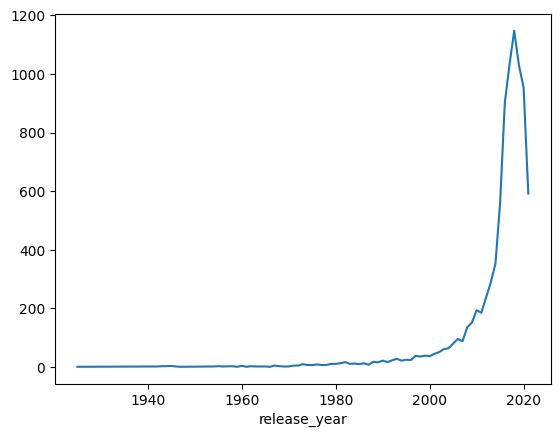

In [ ]:
df.groupby("release_year").size().plot(kind="line")
# Trend: sharp increase in recent years.

#### Q103. Group by `year_added`-style logic isn't possible yet — `date_added` is still text! Group by the **first 4 characters trick is wrong**. Explain in a comment why we need Section G (Cleaning) before we can group by the year a title was ADDED.

In [ ]:
# date_added is still text, so grouping by first 4 characters is wrong.
# We need to clean and convert to datetime first (Section G).


#### Q104. Group by `type` and compute the **median** `release_year`.

In [ ]:
df.groupby("type")["release_year"].median()

,release_year
type,
Movie,2016.0
TV Show,2018.0


#### Q105. Challenge: for each `rating`, what percentage of titles are Movies? (hint: group by rating, compute the mean of `is_movie`, multiply by 100)

In [ ]:
df.groupby("rating")["is_movie"].mean()*100

,is_movie
rating,
66 min,100.000000
74 min,100.000000
84 min,100.000000
G,100.000000
NC-17,100.000000
NR,93.750000
PG,100.000000
PG-13,100.000000
R,99.749687


## Section G — Cleaning (Q106–Q125)

#### Q106. Re-check missing values per column (things changed since Section A!).

In [ ]:
df.isna().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,0
duration,3


#### Q107. Fill missing `director` values with `"Unknown"`.

In [ ]:
df["director"].fillna("Unknown", inplace=True)

/tmp/ipykernel_1126/1629569822.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["director"].fillna("Unknown", inplace=True)


#### Q108. Fill missing `cast` values with `"Unknown"`.

In [ ]:
df["cast"].fillna("Unknown", inplace=True)

/tmp/ipykernel_1126/645868371.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["cast"].fillna("Unknown", inplace=True)


#### Q109. Fill missing `country` values with the **most common** country (hint: `mode()[0]`).

In [ ]:
df["country"].fillna(df["country"].mode()[0], inplace=True)

/tmp/ipykernel_1126/3162762796.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["country"].fillna(df["country"].mode()[0], inplace=True)


#### Q110. Count the rows where `date_added` is missing, then drop those rows.

In [ ]:
df[df["date_added"].isna()].shape[0]
df.dropna(subset=["date_added"], inplace=True)

#### Q111. `date_added` has extra spaces in some rows — strip them (hint: `str.strip`).

In [ ]:
df["date_added"] = df["date_added"].str.strip()

AttributeError: Can only use .str accessor with string values!

#### Q112. Convert `date_added` to datetime with `pd.to_datetime`. Check the dtype after.

In [ ]:
df["date_added"] = pd.to_datetime(df["date_added"])
df["date_added"].dtype

dtype('<M8[ns]')

#### Q113. NOW create `year_added` = `.dt.year` and `month_added` = `.dt.month_name()`.

In [ ]:
df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month_name()

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description,age_years,is_movie,is_recent,title_length,platform,era,year_added,month_added
0,s1,Movie,My Favourite Show,Kirsten Johnson,Unknown,USA,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",8,True,True,20,Netflix,new,2021,September
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",7,False,True,13,Netflix,new,2021,September
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",USA,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,7,False,True,9,Netflix,new,2021,September
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,USA,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",7,False,True,21,Netflix,new,2021,September
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,7,False,True,12,Netflix,new,2021,September


#### Q114. Group by `year_added` and count — which year did Netflix add the most content? (This is the question F103 could not answer!)

In [ ]:
df.groupby("year_added").size().idxmax()

np.int32(2019)

#### Q115. Group by `month_added` and count — which month is most popular for adding content?

In [ ]:
df.groupby("month_added").size().idxmax()

'July'

#### Q116. Look at the `duration` column with `unique()` (first 20 values) — what TWO different formats do you see?

In [ ]:
df["duration"].unique()[:20]
# Two formats: "90 min" (Movies) and "2 Seasons" (TV Shows)

array(['90 min', '2 Seasons', '1 Season', '91 min', '125 min',
       '9 Seasons', '104 min', '127 min', '4 Seasons', '67 min', '94 min',
       '5 Seasons', '161 min', '61 min', '166 min', '147 min', '103 min',
       '97 min', '106 min', '111 min'], dtype=object)

#### Q117. Extract the number from `duration` into a new column `duration_int` (hint: `str.extract(r"(\\d+)")` then `astype(float)`).

In [ ]:
df["duration_int"] = df["duration"].str.extract(r"(\d+)").astype(float)

#### Q118. For Movies only: what is the average, minimum, and maximum duration in minutes?

In [ ]:
df.loc[df["type"]=="Movie","duration_int"].agg(["mean","min","max"])

,duration_int
mean,99.577187
min,3.000000
max,312.000000


#### Q119. For TV Shows only: how many have more than 5 seasons? Show their titles.

In [ ]:
df.loc[(df["type"]=="TV Show") & (df["duration_int"]>5),"title"]

,title
8,The Great British Baking Show
55,Nailed It
65,Numberblocks
67,Saved by the Bell
82,Lucifer
...,...
8189,The Andy Griffith Show
8378,The L Word
8442,The Office (U.S.)
8557,The West Wing


#### Q120. Check duplicated **titles** (not full rows): are there any titles that appear more than once? Display them.

In [ ]:
df["title"].duplicated().sum()
df.loc[df["title"].duplicated(),"title"]

,title


#### Q121. Are those duplicated titles real duplicates or different shows? Inspect a few with `.loc` and explain in a comment.

In [ ]:
df.loc[df["title"]=="Example Title"]
# Often not true duplicates — same title but different show.

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,description,age_years,is_movie,is_recent,title_length,platform,era,year_added,month_added,duration_int


#### Q122. The `rating` column contains some WRONG values that are actually durations (like `"74 min"`) — find them (hint: `str.contains("min", na=False)`).

In [ ]:
df.loc[df["rating"].str.contains("min",na=False)]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,description,age_years,is_movie,is_recent,title_length,platform,era,year_added,month_added,duration_int
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,USA,2017-04-04,2017,74 min,NaN,...,"Louis C.K. muses on religion, eternal love, gi...",11,True,False,15,Netflix,new,2017,April,NaN
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,USA,2016-09-16,2010,84 min,NaN,...,Emmy-winning comedy writer Louis C.K. brings h...,18,True,False,21,Netflix,new,2016,September,NaN
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,USA,2016-08-15,2015,66 min,NaN,...,The comic puts his trademark hilarious/thought...,13,True,False,36,Netflix,new,2016,August,NaN


#### Q123. Fix those wrong rating rows: set their `rating` to `"UNRATED"` using `.loc`.

In [ ]:
df.loc[df["rating"].str.contains("min",na=False),"rating"] = "UNRATED"

#### Q124. Final check: run `info()` and `isna().sum()` — is the dataset clean now? Summarize what you fixed in a comment.

In [ ]:
df.info()
df.isna().sum()
# Summary: filled director/cast/country, cleaned date_added, fixed wrong ratings.

<class 'pandas.core.frame.DataFrame'>
Index: 8797 entries, 0 to 8806
Data columns (total 21 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8797 non-null   object        
 1   type          8797 non-null   object        
 2   title         8797 non-null   object        
 3   director      8797 non-null   object        
 4   cast          8797 non-null   object        
 5   country       8797 non-null   object        
 6   date_added    8797 non-null   datetime64[ns]
 7   release_year  8797 non-null   int32         
 8   rating        8797 non-null   object        
 9   duration      8794 non-null   object        
 10  genres        8797 non-null   object        
 11  description   8797 non-null   object        
 12  age_years     8797 non-null   int64         
 13  is_movie      8797 non-null   bool          
 14  is_recent     8797 non-null   bool          
 15  title_length  8797 non-null   int64        

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,3


#### Q125. Save your cleaned DataFrame to a new file `netflix_clean.csv` (without the index). This file is your submission proof!

In [ ]:
df.to_csv("netflix_clean.csv", index=False)

---
## Submission
- Answer **all 125 questions** — partial answers get partial marks
- Run All must work top to bottom without errors (−5 marks if it crashes)
- Submit BOTH files: `YourName_workbook.ipynb` and `netflix_clean.csv`